In [1]:
import torch

print(torch.cuda.is_available())  # Should return True if CUDA is detected
print(torch.__version__)  # Example output: '2.1.0+cpu' or '2.1.0+cu118'


False
2.6.0+cu124


In [2]:
import gym
import procgen
%load_ext autoreload
%autoreload 2

# Setup Environment

In [3]:
from wrapped_procgen import make_wrapped_procgen_env

env = make_wrapped_procgen_env("procgen:procgen-coinrun-v0", starting_level=0, num_levels=10)

/storage/home/hcoda1/4/rmehta98/p-adelarue3-0/rl_env2/lib/python3.9/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/storage/home/hcoda1/4/rmehta98/p-adelarue3-0/rl_env2/lib/python3.9/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/storage/home/hcoda1/4/rmehta98/p-adelarue3-0/rl_env2/lib/python3.9/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/storage/home/hcoda1/

# Load Last Model

In [9]:
save_folder = "/storage/home/hcoda1/4/rmehta98/p-adelarue3-0/impala_10env_25m_easy/"

In [12]:
from utils import get_filename_with_highest_timestep
checkpoint, highest_timestep = get_filename_with_highest_timestep(save_folder)
checkpoint

'v20250305_2202_2816000_steps.zip'

In [13]:
from stable_baselines3 import PPO
import os
model_loaded = PPO.load(os.path.join(save_folder, checkpoint), env=env)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


## Fresh Model

In [4]:
from stable_baselines3 import PPO
from impala import ImpalaActorCriticPolicy

model = PPO(
            ImpalaActorCriticPolicy,
            env,
            n_steps = 500, # timesteps before updating weights
            learning_rate=5e-4,  # 5 × 10^−4
            batch_size=32,  # n_steps / minibatches (256 / 8)
            n_epochs=3,  # Epochs per rollout
            gamma=0.999,  # Discount factor
            gae_lambda=0.95,  # GAE parameter
            ent_coef=0.01,  # Entropy bonus
            clip_range=0.2,  # PPO clipping range
            normalize_advantage=True,  # Reward normalization
            device="cuda",
            verbose=1,)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


/storage/home/hcoda1/4/rmehta98/p-adelarue3-0/rl_env2/lib/python3.9/site-packages/stable_baselines3/ppo/ppo.py:155: UserWarning: You have specified a mini-batch size of 32, but because the `RolloutBuffer` is of size `n_steps * n_envs = 500`, after every 15 untruncated mini-batches, there will be a truncated mini-batch of size 20
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=500 and n_envs=1)
  warnings.warn(


In [9]:
obs, _ = env.reset()
model.predict(obs)

(array(13), None)

# Eval

In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [7]:
from stable_baselines3.common.evaluation import evaluate_policy


mean_reward, std_reward = evaluate_policy(model, model.get_env(), n_eval_episodes=10)
mean_reward, std_reward

(0.0, 0.0)

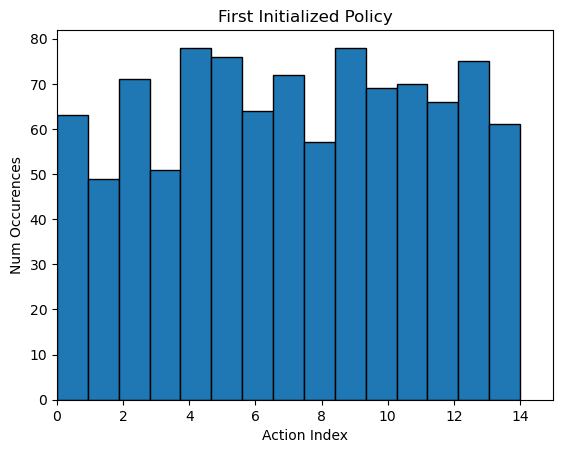

[2, 12, 10, 7, 13, 12, 13, 7, 9, 8, 12, 13, 10, 9, 12, 3, 11, 0, 10, 7, 5, 5, 1, 6, 11, 14, 7, 4, 4, 0, 4, 5, 3, 9, 4, 9, 11, 9, 10, 12, 12, 12, 7, 13, 0, 3, 13, 12, 0, 7, 13, 4, 11, 11, 6, 0, 12, 13, 5, 9, 13, 14, 3, 6, 9, 0, 5, 11, 7, 1, 12, 10, 5, 13, 10, 10, 11, 2, 11, 7, 12, 6, 10, 9, 12, 5, 5, 9, 3, 9, 0, 12, 10, 3, 1, 9, 8, 13, 14, 13, 14, 10, 6, 9, 5, 12, 4, 0, 10, 10, 2, 10, 12, 10, 10, 9, 12, 14, 1, 12, 14, 2, 14, 7, 6, 7, 12, 7, 2, 11, 2, 9, 6, 4, 11, 9, 5, 9, 6, 10, 2, 10, 2, 7, 14, 10, 8, 7, 5, 5, 0, 10, 10, 0, 7, 9, 10, 0, 11, 14, 8, 11, 10, 7, 12, 14, 13, 9, 1, 8, 13, 2, 5, 12, 13, 1, 0, 4, 8, 9, 10, 7, 13, 14, 10, 5, 0, 14, 3, 0, 4, 4, 7, 0, 11, 12, 4, 13, 2, 3, 5, 1, 12, 8, 14, 7, 9, 0, 4, 5, 6, 0, 7, 4, 13, 9, 11, 12, 1, 10, 13, 9, 9, 14, 4, 3, 5, 6, 14, 2, 12, 7, 8, 4, 9, 9, 10, 11, 6, 6, 6, 10, 13, 3, 3, 8, 14, 7, 4, 13, 7, 14, 4, 0, 3, 11, 10, 0, 0, 2, 4, 8, 9, 2, 1, 11, 4, 14, 5, 0, 14, 9, 4, 14, 13, 13, 7, 10, 6, 1, 6, 14, 11, 13, 9, 8, 4, 8, 1, 14, 10, 4, 6, 0, 

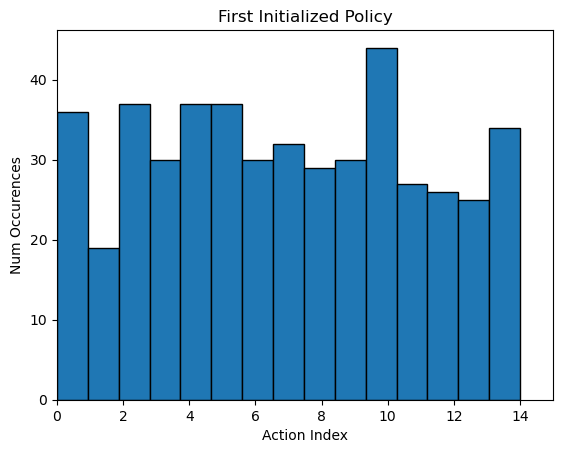

[13, 7, 1, 14, 12, 11, 7, 0, 5, 2, 0, 0, 11, 7, 9, 10, 8, 0, 7, 10, 7, 14, 14, 4, 10, 9, 4, 2, 4, 4, 11, 0, 9, 14, 13, 13, 3, 12, 5, 3, 3, 6, 14, 8, 7, 1, 1, 10, 9, 5, 5, 12, 5, 10, 1, 6, 7, 6, 10, 7, 0, 14, 14, 12, 8, 0, 13, 14, 1, 9, 6, 3, 11, 13, 2, 1, 6, 9, 13, 12, 0, 2, 0, 7, 1, 4, 0, 6, 0, 11, 11, 4, 13, 13, 9, 10, 3, 2, 9, 2, 12, 2, 5, 6, 10, 14, 4, 9, 6, 12, 13, 7, 14, 6, 10, 2, 14, 7, 7, 4, 10, 9, 0, 0, 6, 14, 10, 14, 14, 10, 14, 6, 10, 2, 12, 2, 10, 2, 14, 9, 10, 10, 4, 4, 6, 12, 4, 11, 13, 4, 9, 2, 2, 10, 11, 14, 11, 1, 14, 4, 13, 10, 3, 9, 8, 7, 3, 5, 0, 14, 5, 5, 8, 4, 8, 3, 5, 5, 1, 12, 3, 4, 8, 10, 11, 7, 9, 11, 9, 13, 7, 1, 0, 4, 2, 6, 3, 1, 0, 10, 5, 5, 9, 3, 0, 4, 1, 4, 3, 4, 5, 1, 5, 8, 8, 5, 3, 13, 2, 4, 12, 5, 2, 0, 4, 12, 4, 2, 10, 11, 2, 4, 7, 3, 6, 8, 0, 14, 5, 6, 2, 11, 2, 10, 12, 0, 5, 11, 5, 7, 8, 13, 7, 10, 10, 9, 4, 3, 11, 9, 5, 14, 8, 12, 3, 0, 11, 13, 8, 12, 0, 9, 4, 13, 12, 5, 2, 3, 8, 2, 14, 1, 10, 10, 6, 5, 7, 3, 2, 13, 7, 1, 0, 1, 9, 4, 4, 9, 2, 6, 9,

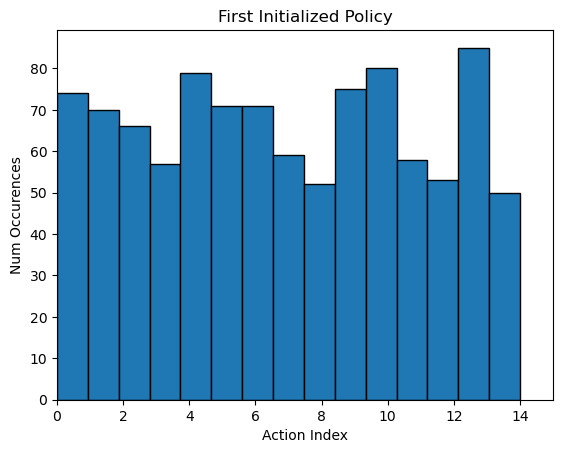

[8, 1, 4, 1, 5, 14, 14, 13, 2, 13, 1, 0, 0, 10, 2, 7, 3, 6, 6, 5, 5, 8, 10, 13, 13, 3, 10, 9, 2, 0, 11, 0, 1, 10, 13, 5, 10, 13, 9, 11, 4, 4, 14, 6, 7, 2, 3, 2, 12, 2, 7, 10, 6, 14, 3, 8, 13, 14, 10, 9, 10, 0, 11, 3, 6, 3, 5, 11, 10, 7, 14, 2, 4, 3, 2, 7, 2, 8, 13, 9, 5, 8, 2, 12, 11, 6, 4, 6, 10, 3, 3, 13, 5, 4, 4, 9, 2, 2, 11, 6, 10, 11, 14, 10, 1, 4, 5, 0, 8, 2, 4, 7, 1, 10, 9, 9, 12, 12, 9, 6, 13, 1, 12, 4, 7, 8, 0, 7, 8, 9, 13, 1, 4, 1, 1, 11, 10, 2, 10, 3, 9, 12, 10, 12, 1, 7, 9, 12, 6, 3, 8, 1, 7, 0, 2, 2, 5, 11, 2, 1, 1, 2, 14, 1, 1, 11, 3, 1, 3, 7, 4, 10, 3, 13, 13, 0, 5, 14, 4, 6, 9, 7, 9, 0, 5, 3, 9, 13, 4, 0, 13, 1, 4, 10, 14, 8, 12, 13, 14, 6, 11, 9, 0, 3, 7, 7, 1, 6, 0, 13, 14, 5, 11, 0, 4, 10, 11, 1, 0, 14, 0, 10, 13, 4, 13, 11, 1, 7, 0, 9, 3, 0, 2, 0, 13, 6, 10, 2, 6, 6, 9, 10, 6, 13, 13, 1, 10, 3, 0, 11, 1, 13, 4, 1, 5, 8, 8, 2, 11, 9, 1, 0, 0, 10, 4, 14, 0, 13, 11, 0, 4, 6, 2, 8, 1, 4, 0, 10, 3, 0, 0, 13, 7, 13, 14, 3, 5, 11, 14, 10, 4, 13, 4, 12, 4, 13, 4, 7, 0, 13, 

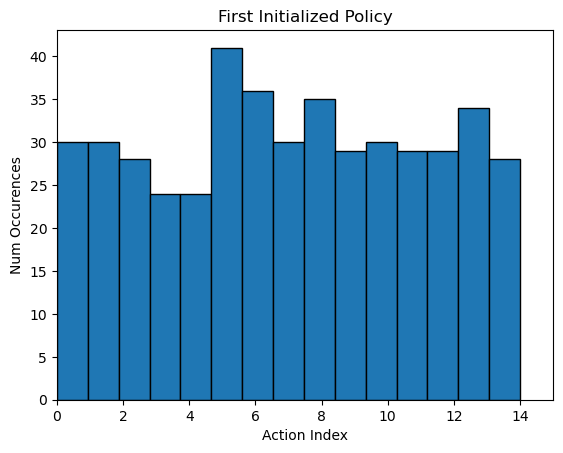

[6, 13, 0, 13, 13, 5, 8, 1, 6, 0, 6, 5, 2, 3, 5, 10, 8, 14, 3, 9, 8, 12, 3, 13, 14, 11, 0, 5, 12, 12, 0, 10, 11, 12, 1, 8, 5, 5, 0, 11, 7, 11, 9, 0, 5, 2, 6, 6, 9, 2, 1, 1, 11, 2, 13, 4, 12, 14, 11, 8, 1, 3, 4, 12, 8, 5, 4, 10, 5, 9, 6, 4, 8, 13, 0, 13, 0, 4, 12, 12, 12, 3, 12, 10, 13, 3, 1, 6, 5, 8, 1, 12, 12, 14, 2, 9, 13, 14, 8, 7, 14, 8, 9, 8, 6, 4, 3, 5, 10, 1, 4, 4, 1, 11, 5, 9, 4, 13, 0, 8, 14, 1, 10, 13, 2, 7, 11, 10, 7, 4, 7, 14, 2, 1, 2, 9, 8, 4, 5, 12, 13, 14, 1, 2, 9, 2, 0, 14, 0, 13, 4, 10, 14, 10, 13, 11, 10, 12, 2, 5, 11, 8, 10, 11, 0, 9, 7, 13, 13, 6, 8, 14, 4, 5, 14, 1, 5, 5, 3, 7, 6, 13, 1, 8, 11, 13, 10, 4, 7, 9, 10, 5, 8, 0, 3, 1, 1, 13, 2, 10, 2, 0, 6, 3, 2, 10, 12, 9, 11, 13, 12, 7, 9, 8, 6, 10, 0, 7, 9, 0, 6, 6, 3, 1, 3, 14, 13, 7, 3, 1, 1, 10, 3, 3, 8, 8, 8, 14, 2, 0, 6, 5, 9, 3, 3, 5, 1, 13, 9, 5, 6, 9, 4, 4, 14, 0, 4, 5, 7, 2, 11, 7, 13, 1, 14, 7, 6, 6, 0, 8, 14, 11, 2, 5, 7, 5, 6, 11, 5, 5, 0, 4, 8, 12, 4, 10, 0, 4, 11, 11, 1, 13, 4, 9, 2, 11, 12, 9, 6, 12, 7

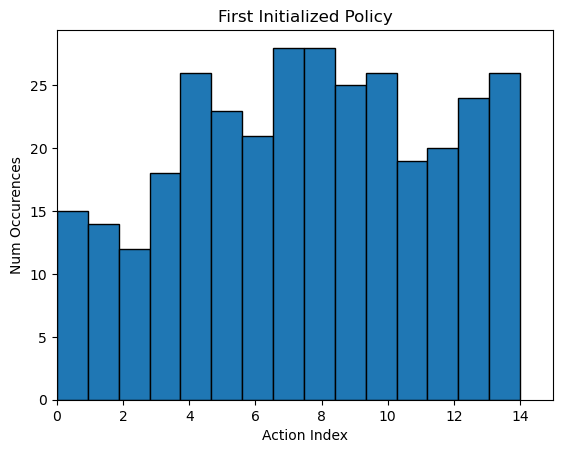

[9, 0, 9, 8, 4, 10, 8, 7, 3, 14, 11, 2, 10, 9, 0, 3, 9, 4, 13, 10, 14, 4, 12, 7, 4, 9, 8, 1, 2, 4, 5, 3, 14, 9, 6, 11, 12, 1, 7, 7, 8, 13, 10, 14, 13, 4, 4, 4, 5, 3, 13, 1, 0, 9, 10, 6, 11, 11, 6, 8, 5, 5, 12, 3, 5, 11, 0, 14, 8, 8, 4, 6, 9, 7, 2, 7, 6, 6, 14, 5, 6, 4, 7, 1, 10, 2, 3, 4, 3, 13, 13, 4, 14, 13, 14, 7, 2, 8, 13, 8, 7, 11, 5, 9, 1, 0, 2, 8, 11, 5, 0, 1, 4, 14, 7, 13, 3, 6, 5, 7, 3, 9, 7, 14, 4, 0, 13, 7, 9, 4, 12, 10, 12, 0, 9, 7, 13, 10, 0, 12, 4, 10, 9, 12, 12, 4, 14, 11, 7, 11, 5, 4, 9, 6, 3, 10, 12, 10, 13, 11, 13, 8, 1, 8, 5, 14, 8, 10, 9, 12, 5, 9, 8, 14, 13, 14, 12, 5, 1, 2, 13, 10, 14, 6, 6, 6, 13, 9, 0, 8, 10, 10, 14, 13, 6, 7, 7, 3, 11, 14, 11, 11, 7, 12, 7, 2, 6, 9, 13, 5, 4, 3, 4, 10, 9, 14, 2, 8, 1, 9, 3, 10, 8, 5, 4, 4, 9, 11, 1, 8, 6, 1, 10, 4, 11, 2, 1, 10, 13, 3, 8, 11, 9, 7, 5, 13, 5, 8, 13, 10, 6, 8, 12, 10, 0, 12, 1, 14, 6, 10, 6, 8, 8, 3, 6, 4, 12, 11, 12, 0, 4, 10, 6, 5, 7, 10, 14, 13, 7, 6, 3, 9, 0, 0, 10, 9, 9, 7, 8, 14, 2, 8, 0, 2, 3, 12, 3, 13, 4,

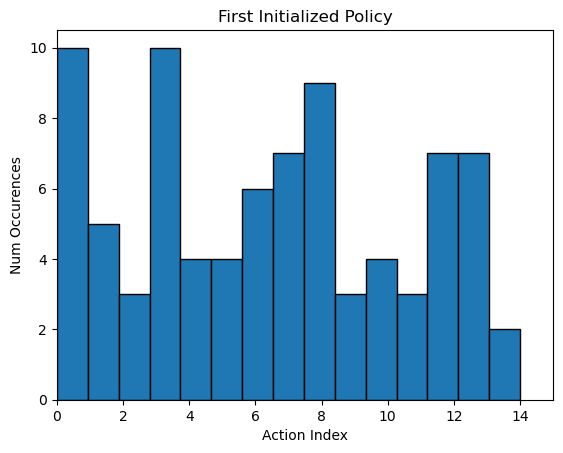

[0, 9, 1, 9, 0, 7, 14, 3, 3, 10, 13, 8, 6, 13, 7, 0, 14, 3, 8, 4, 8, 0, 3, 10, 13, 8, 5, 12, 7, 12, 7, 7, 2, 13, 2, 0, 0, 0, 1, 10, 13, 0, 12, 8, 7, 8, 8, 3, 6, 5, 10, 1, 1, 6, 11, 5, 3, 0, 4, 13, 1, 2, 13, 4, 7, 12, 3, 8, 11, 12, 6, 12, 9, 6, 3, 12, 4, 11, 6, 0, 8, 3, 3, 5]
Episode 6 terminated with reward of 0.0 (step 84)


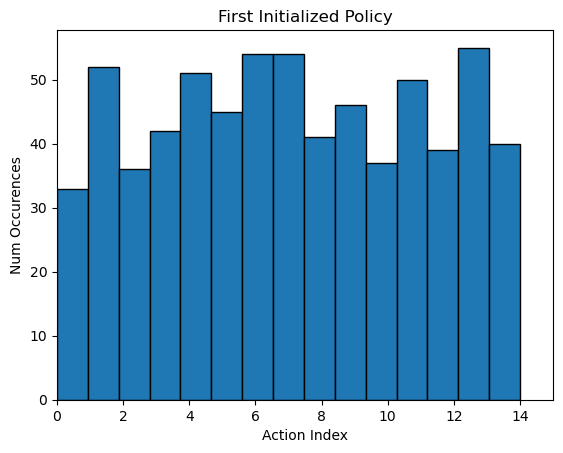

[13, 2, 1, 13, 6, 1, 7, 3, 9, 13, 6, 7, 4, 12, 6, 6, 4, 3, 4, 7, 4, 8, 6, 3, 14, 10, 4, 7, 0, 10, 11, 0, 12, 14, 1, 4, 6, 9, 9, 4, 8, 7, 0, 8, 0, 1, 8, 12, 12, 1, 11, 7, 2, 0, 6, 9, 4, 8, 2, 13, 12, 3, 13, 4, 0, 12, 9, 0, 13, 12, 5, 8, 8, 13, 1, 14, 2, 7, 12, 1, 11, 7, 11, 13, 12, 4, 9, 4, 7, 13, 11, 6, 12, 8, 6, 6, 14, 12, 12, 4, 9, 10, 12, 9, 10, 4, 10, 14, 10, 4, 6, 1, 8, 2, 13, 1, 1, 11, 13, 9, 14, 9, 1, 6, 3, 2, 11, 12, 3, 13, 1, 3, 4, 2, 4, 9, 7, 11, 14, 9, 5, 3, 3, 0, 5, 12, 13, 5, 9, 3, 13, 10, 9, 3, 11, 6, 1, 9, 6, 12, 10, 5, 1, 3, 13, 3, 4, 12, 11, 10, 5, 4, 9, 4, 5, 12, 6, 6, 9, 10, 9, 7, 12, 13, 10, 13, 5, 1, 5, 1, 5, 11, 1, 1, 4, 11, 14, 2, 11, 11, 7, 11, 13, 3, 12, 4, 14, 4, 5, 14, 4, 4, 4, 12, 0, 7, 11, 10, 2, 6, 7, 7, 9, 2, 2, 8, 13, 10, 0, 13, 1, 5, 9, 1, 7, 6, 11, 9, 3, 6, 6, 0, 3, 2, 2, 6, 14, 2, 5, 12, 6, 2, 10, 14, 7, 3, 1, 14, 5, 2, 9, 2, 8, 10, 8, 14, 1, 8, 6, 3, 0, 3, 7, 0, 5, 1, 6, 1, 5, 10, 8, 13, 14, 3, 11, 10, 13, 14, 2, 11, 8, 14, 4, 6, 5, 13, 7, 12, 6, 6, 

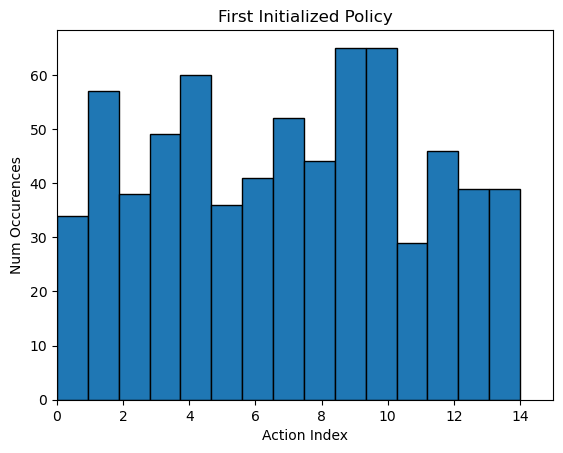

[7, 1, 13, 6, 12, 12, 3, 3, 11, 10, 12, 1, 9, 8, 6, 1, 4, 10, 14, 10, 8, 9, 2, 1, 12, 8, 2, 9, 6, 4, 5, 7, 2, 9, 9, 0, 9, 2, 11, 4, 9, 6, 3, 2, 0, 12, 1, 7, 0, 2, 5, 3, 5, 5, 14, 5, 1, 13, 2, 8, 10, 6, 7, 10, 2, 10, 6, 1, 1, 1, 13, 4, 13, 10, 4, 4, 9, 2, 11, 9, 8, 7, 10, 10, 13, 10, 11, 13, 1, 9, 10, 9, 14, 12, 11, 1, 1, 14, 9, 7, 14, 10, 6, 12, 3, 4, 2, 4, 6, 11, 11, 4, 7, 14, 6, 10, 10, 1, 13, 10, 1, 7, 4, 1, 0, 9, 6, 4, 1, 1, 12, 9, 5, 11, 2, 12, 0, 3, 12, 10, 11, 1, 8, 10, 3, 1, 6, 8, 10, 12, 2, 1, 9, 6, 8, 7, 14, 14, 3, 12, 5, 12, 8, 0, 4, 9, 2, 12, 7, 9, 6, 7, 1, 10, 1, 14, 10, 5, 4, 7, 6, 9, 9, 4, 14, 11, 12, 14, 9, 10, 9, 7, 9, 8, 9, 12, 8, 4, 8, 9, 9, 9, 6, 12, 0, 14, 7, 7, 10, 1, 6, 6, 13, 6, 7, 8, 5, 4, 8, 3, 9, 6, 11, 8, 10, 10, 7, 0, 9, 12, 4, 1, 10, 4, 0, 14, 6, 4, 14, 8, 13, 12, 7, 0, 2, 0, 3, 14, 7, 10, 13, 8, 12, 1, 2, 10, 7, 3, 9, 4, 1, 4, 9, 8, 9, 1, 13, 8, 7, 4, 0, 9, 8, 12, 3, 4, 1, 13, 3, 7, 3, 7, 13, 1, 13, 7, 13, 2, 6, 13, 11, 14, 12, 13, 5, 1, 1, 1, 7, 13, 0, 1

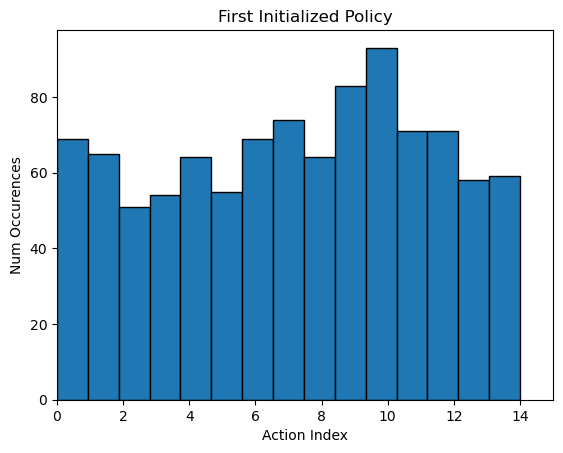

[4, 14, 13, 8, 3, 11, 2, 7, 6, 8, 12, 8, 6, 9, 11, 1, 4, 10, 10, 6, 4, 10, 12, 6, 13, 11, 6, 9, 1, 12, 2, 0, 3, 1, 12, 14, 2, 10, 3, 7, 13, 7, 11, 10, 9, 7, 13, 6, 8, 4, 7, 14, 13, 4, 4, 2, 5, 14, 7, 13, 0, 1, 5, 9, 7, 3, 9, 4, 6, 2, 13, 5, 2, 5, 7, 2, 12, 1, 6, 13, 10, 0, 0, 14, 9, 2, 12, 13, 10, 10, 2, 7, 9, 7, 5, 13, 7, 14, 7, 4, 9, 10, 7, 12, 6, 13, 10, 0, 10, 0, 8, 0, 10, 0, 14, 8, 12, 7, 1, 1, 13, 11, 12, 5, 7, 6, 3, 2, 0, 13, 8, 0, 14, 1, 9, 7, 12, 0, 1, 0, 12, 10, 8, 11, 8, 11, 6, 13, 8, 12, 6, 13, 1, 11, 7, 6, 8, 14, 7, 13, 9, 14, 3, 1, 11, 1, 12, 9, 10, 1, 2, 1, 11, 10, 14, 2, 6, 9, 4, 8, 10, 8, 7, 12, 8, 0, 13, 14, 11, 10, 11, 3, 7, 9, 13, 9, 9, 5, 12, 10, 9, 9, 13, 4, 9, 2, 3, 1, 6, 0, 1, 4, 1, 10, 12, 6, 5, 5, 8, 14, 8, 4, 3, 4, 10, 10, 1, 5, 12, 14, 5, 3, 9, 12, 1, 4, 13, 9, 4, 12, 7, 5, 1, 7, 14, 5, 0, 12, 14, 10, 9, 0, 8, 8, 11, 9, 8, 11, 10, 11, 6, 12, 4, 1, 4, 2, 9, 7, 10, 6, 9, 5, 14, 10, 5, 9, 6, 12, 8, 9, 3, 2, 12, 5, 10, 2, 5, 3, 1, 0, 11, 10, 0, 5, 6, 2, 8, 10, 6

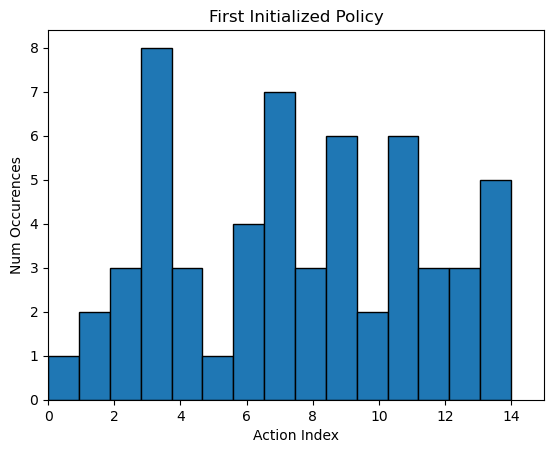

[2, 7, 4, 2, 9, 0, 11, 4, 10, 6, 2, 4, 9, 3, 12, 5, 11, 1, 12, 7, 13, 7, 11, 3, 14, 1, 10, 13, 3, 7, 11, 14, 9, 3, 3, 6, 6, 14, 9, 6, 14, 14, 7, 7, 8, 3, 3, 11, 8, 3, 8, 12, 7, 13, 9, 11, 9]
Episode 10 terminated with reward of 0.0 (step 57)


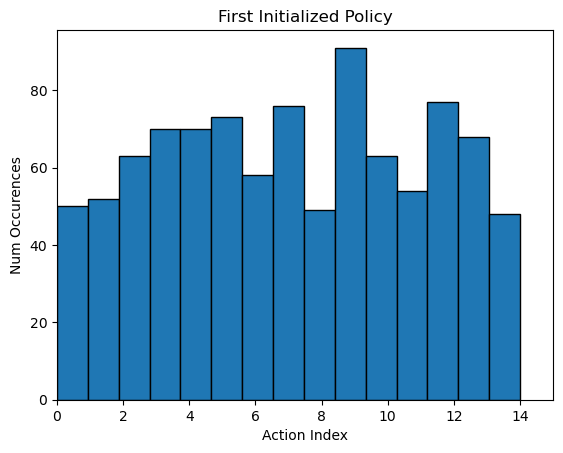

[9, 2, 8, 9, 3, 3, 13, 0, 13, 2, 1, 0, 6, 2, 6, 12, 14, 7, 13, 14, 4, 1, 4, 6, 11, 7, 5, 4, 14, 13, 3, 10, 9, 0, 3, 4, 9, 6, 11, 5, 9, 2, 2, 2, 11, 11, 0, 12, 4, 11, 3, 9, 11, 2, 11, 3, 9, 9, 11, 9, 14, 10, 10, 1, 6, 1, 3, 11, 2, 12, 1, 1, 6, 5, 9, 13, 10, 8, 5, 12, 5, 0, 5, 9, 7, 3, 14, 1, 9, 4, 12, 5, 7, 7, 4, 11, 11, 6, 9, 7, 6, 8, 7, 10, 11, 14, 7, 7, 1, 9, 9, 6, 0, 0, 5, 6, 4, 9, 8, 14, 7, 4, 0, 4, 9, 9, 5, 5, 8, 9, 13, 10, 10, 3, 5, 10, 10, 12, 3, 5, 6, 14, 5, 10, 9, 13, 1, 13, 3, 5, 14, 3, 11, 1, 12, 11, 1, 8, 6, 2, 7, 0, 1, 4, 7, 10, 4, 6, 2, 7, 11, 9, 8, 5, 3, 10, 0, 9, 14, 12, 4, 9, 5, 1, 7, 11, 9, 13, 12, 14, 8, 5, 2, 3, 10, 9, 7, 2, 13, 2, 13, 4, 8, 2, 9, 4, 6, 9, 3, 3, 12, 7, 3, 11, 1, 9, 1, 12, 4, 7, 8, 3, 14, 14, 2, 7, 13, 7, 9, 2, 5, 11, 5, 9, 9, 12, 2, 12, 8, 9, 14, 13, 5, 11, 9, 9, 0, 8, 10, 12, 1, 9, 12, 5, 7, 2, 0, 11, 13, 1, 4, 3, 10, 4, 4, 7, 9, 10, 11, 2, 3, 13, 12, 4, 7, 9, 9, 5, 13, 2, 2, 1, 7, 1, 6, 1, 13, 6, 9, 13, 13, 8, 3, 5, 4, 3, 2, 14, 8, 12, 12, 5, 11, 

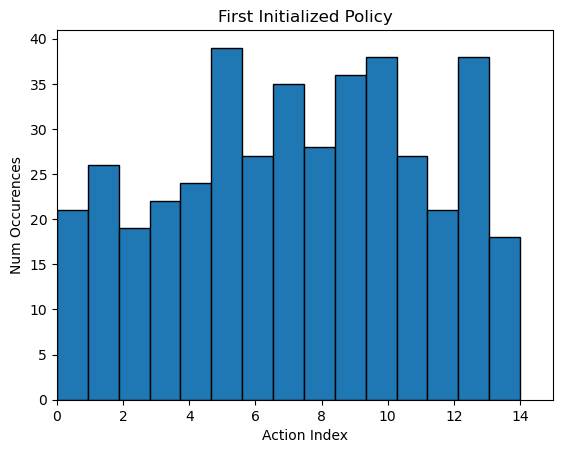

[12, 5, 11, 10, 4, 6, 11, 7, 2, 13, 4, 5, 0, 6, 10, 6, 1, 10, 13, 10, 5, 12, 14, 1, 4, 5, 8, 13, 12, 9, 7, 13, 3, 10, 2, 13, 14, 2, 1, 13, 8, 4, 9, 9, 9, 2, 13, 12, 7, 13, 5, 5, 10, 6, 1, 8, 8, 5, 13, 3, 0, 7, 5, 1, 13, 10, 13, 14, 14, 0, 1, 5, 10, 11, 3, 7, 4, 0, 10, 4, 13, 3, 12, 8, 8, 2, 7, 13, 11, 10, 8, 3, 0, 3, 1, 14, 11, 5, 2, 10, 13, 4, 6, 12, 1, 3, 4, 1, 9, 5, 14, 4, 13, 13, 12, 9, 5, 4, 12, 6, 2, 6, 10, 5, 13, 9, 13, 5, 10, 0, 3, 10, 12, 5, 2, 9, 5, 0, 13, 9, 7, 8, 5, 13, 1, 3, 14, 5, 10, 1, 14, 7, 11, 9, 8, 11, 0, 4, 8, 6, 11, 4, 9, 6, 6, 1, 8, 10, 5, 3, 4, 4, 4, 13, 9, 13, 1, 6, 11, 6, 11, 3, 10, 9, 5, 9, 0, 11, 2, 9, 7, 10, 14, 8, 13, 13, 11, 14, 14, 7, 10, 14, 5, 14, 7, 11, 7, 9, 10, 5, 9, 4, 2, 9, 10, 10, 0, 7, 11, 2, 1, 9, 10, 9, 11, 5, 9, 7, 7, 5, 9, 8, 5, 6, 3, 9, 6, 1, 9, 1, 9, 6, 8, 5, 0, 5, 1, 6, 10, 7, 10, 7, 4, 1, 13, 11, 13, 12, 3, 13, 8, 7, 12, 7, 7, 10, 6, 9, 7, 5, 1, 8, 3, 9, 13, 3, 9, 4, 8, 10, 0, 5, 12, 13, 14, 3, 7, 9, 8, 8, 7, 13, 0, 10, 12, 8, 8, 4, 12, 

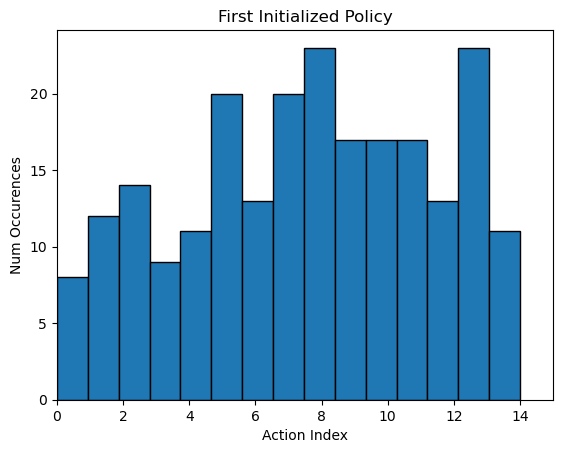

[4, 12, 12, 8, 9, 13, 13, 11, 13, 8, 5, 2, 7, 1, 8, 9, 5, 8, 3, 14, 5, 6, 8, 7, 12, 5, 11, 2, 2, 7, 13, 2, 8, 2, 12, 7, 6, 6, 13, 11, 6, 9, 11, 0, 5, 6, 5, 8, 14, 11, 7, 11, 5, 11, 4, 8, 13, 10, 5, 13, 1, 11, 7, 7, 1, 2, 10, 4, 8, 0, 10, 7, 7, 4, 13, 9, 9, 8, 3, 14, 7, 8, 2, 9, 7, 11, 1, 12, 5, 12, 13, 5, 13, 2, 11, 6, 6, 9, 12, 5, 4, 13, 6, 7, 14, 3, 13, 11, 7, 13, 10, 8, 12, 6, 2, 14, 6, 10, 10, 13, 12, 5, 11, 13, 5, 14, 2, 12, 14, 10, 0, 1, 8, 13, 1, 0, 13, 10, 14, 14, 7, 5, 4, 9, 8, 11, 0, 3, 4, 13, 5, 9, 5, 1, 8, 9, 7, 7, 11, 3, 4, 1, 11, 1, 3, 10, 12, 0, 7, 9, 10, 6, 1, 10, 13, 12, 4, 8, 9, 7, 10, 10, 2, 8, 12, 8, 2, 2, 13, 6, 8, 5, 1, 8, 10, 9, 10, 3, 7, 14, 7, 6, 9, 3, 2, 10, 9, 9, 4, 0, 10, 11, 5, 4, 5, 5, 13, 8, 3, 13, 14, 13, 8, 0, 9, 1, 11, 8]
Episode 13 terminated with reward of 0.0 (step 228)


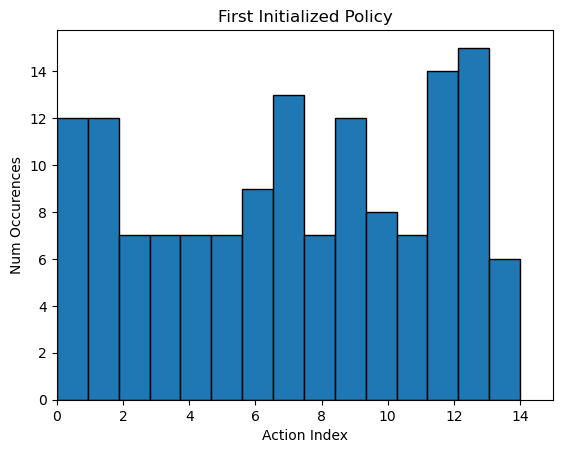

[6, 13, 7, 9, 13, 13, 0, 14, 9, 10, 8, 5, 2, 8, 2, 0, 3, 1, 12, 10, 1, 3, 1, 13, 7, 8, 12, 12, 9, 10, 7, 13, 13, 10, 1, 5, 1, 5, 4, 12, 2, 1, 13, 3, 8, 1, 14, 12, 7, 1, 5, 11, 12, 12, 14, 13, 0, 12, 7, 12, 13, 13, 10, 1, 8, 0, 14, 0, 7, 2, 7, 11, 4, 5, 10, 6, 6, 12, 12, 1, 9, 9, 13, 6, 6, 0, 3, 7, 2, 4, 6, 6, 7, 9, 0, 0, 13, 9, 2, 4, 7, 10, 9, 6, 3, 11, 9, 1, 11, 7, 6, 12, 8, 13, 0, 11, 4, 12, 0, 2, 11, 9, 0, 4, 14, 1, 7, 5, 7, 13, 8, 0, 12, 4, 9, 9, 10, 3, 14, 13, 5, 11, 3]
Episode 14 terminated with reward of 0.0 (step 143)


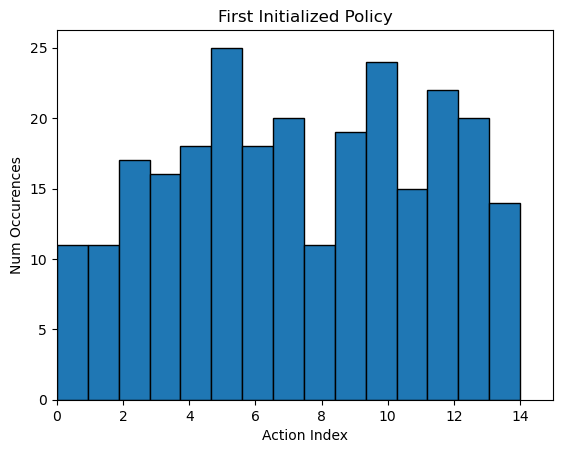

[11, 7, 12, 13, 9, 3, 13, 13, 9, 4, 9, 2, 5, 14, 13, 6, 12, 10, 13, 13, 11, 7, 10, 10, 7, 10, 5, 12, 9, 14, 5, 6, 3, 10, 14, 11, 0, 13, 10, 9, 4, 1, 0, 7, 10, 2, 0, 7, 11, 10, 13, 0, 1, 5, 12, 2, 6, 14, 8, 0, 10, 4, 6, 12, 5, 5, 4, 1, 4, 2, 8, 10, 10, 2, 6, 5, 11, 10, 13, 2, 10, 2, 12, 9, 3, 11, 6, 8, 10, 11, 14, 12, 12, 3, 12, 5, 3, 1, 10, 3, 3, 2, 2, 1, 12, 11, 6, 14, 12, 9, 4, 11, 12, 6, 12, 9, 11, 7, 8, 4, 2, 4, 5, 6, 9, 7, 6, 0, 0, 13, 10, 3, 5, 3, 2, 12, 7, 3, 4, 7, 8, 4, 0, 4, 9, 8, 0, 7, 14, 14, 2, 1, 0, 7, 4, 14, 4, 8, 0, 5, 9, 10, 13, 10, 9, 11, 5, 5, 13, 4, 7, 6, 13, 10, 12, 7, 12, 7, 14, 14, 5, 3, 13, 7, 13, 6, 10, 12, 14, 2, 7, 4, 12, 13, 10, 13, 5, 3, 14, 6, 2, 1, 3, 13, 5, 9, 6, 7, 2, 9, 5, 3, 5, 5, 9, 6, 10, 12, 11, 9, 5, 9, 8, 6, 2, 9, 8, 5, 12, 1, 13, 7, 1, 5, 12, 5, 1, 11, 4, 8, 10, 4, 5, 7, 2, 11, 3, 10, 13, 8, 14, 6, 5, 1, 9, 3, 4, 7, 11, 12, 6]
Episode 15 terminated with reward of 0.0 (step 261)


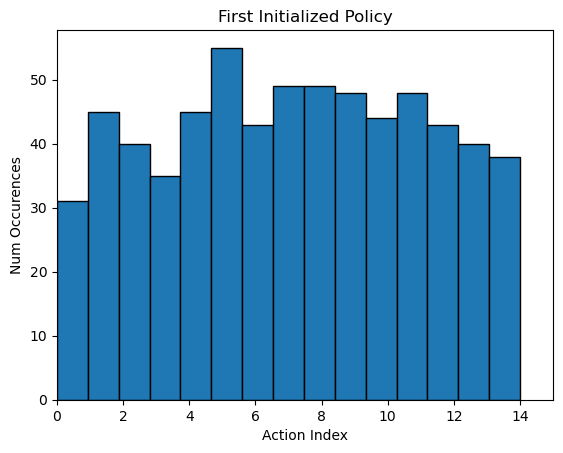

[2, 4, 0, 9, 5, 3, 14, 4, 13, 1, 5, 11, 5, 2, 0, 4, 6, 6, 12, 11, 11, 9, 2, 0, 1, 3, 1, 11, 5, 5, 11, 13, 1, 3, 5, 8, 7, 11, 11, 3, 3, 10, 0, 10, 9, 9, 1, 5, 12, 4, 7, 1, 0, 14, 3, 10, 7, 8, 9, 10, 13, 2, 3, 5, 5, 12, 13, 0, 13, 10, 1, 0, 2, 10, 11, 9, 5, 9, 4, 0, 11, 8, 1, 6, 7, 2, 0, 7, 6, 2, 6, 14, 0, 11, 8, 9, 11, 3, 3, 8, 14, 5, 11, 10, 9, 5, 9, 11, 11, 12, 4, 7, 14, 9, 3, 9, 8, 7, 1, 13, 13, 7, 7, 1, 9, 10, 6, 11, 5, 11, 14, 10, 7, 5, 7, 0, 7, 5, 7, 7, 12, 2, 2, 10, 12, 12, 0, 5, 7, 1, 1, 7, 12, 6, 3, 3, 2, 12, 7, 12, 0, 13, 13, 11, 11, 7, 4, 1, 11, 0, 2, 13, 5, 10, 6, 0, 5, 11, 1, 6, 3, 8, 1, 11, 8, 12, 6, 13, 10, 0, 14, 8, 5, 1, 5, 7, 5, 9, 3, 4, 10, 5, 5, 1, 6, 12, 12, 9, 9, 0, 1, 14, 10, 14, 12, 7, 14, 8, 7, 11, 0, 1, 9, 14, 10, 2, 9, 8, 14, 2, 9, 7, 5, 7, 2, 11, 3, 3, 10, 11, 13, 4, 3, 8, 9, 10, 10, 5, 11, 5, 9, 10, 12, 13, 10, 2, 6, 10, 5, 0, 12, 7, 8, 9, 0, 5, 0, 13, 1, 12, 4, 4, 5, 2, 7, 11, 12, 2, 8, 6, 4, 6, 13, 7, 10, 12, 13, 12, 10, 11, 3, 1, 2, 8, 8, 5, 1, 14, 7, 4, 

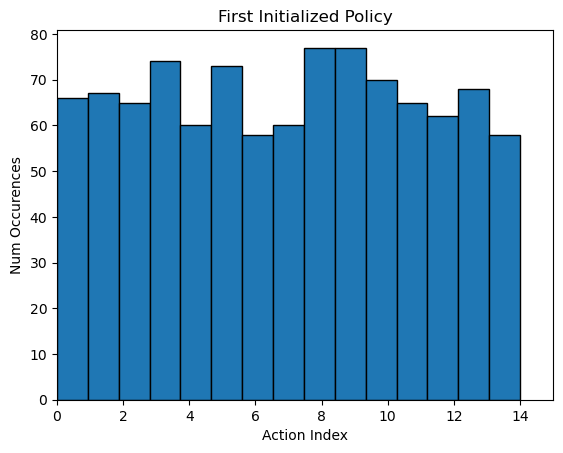

[10, 7, 8, 14, 6, 2, 11, 2, 9, 4, 1, 2, 13, 6, 4, 13, 8, 8, 8, 11, 13, 2, 11, 13, 5, 8, 6, 8, 1, 12, 9, 5, 4, 10, 0, 10, 10, 10, 5, 11, 9, 9, 5, 3, 8, 3, 11, 13, 6, 5, 3, 12, 13, 13, 3, 10, 14, 10, 1, 9, 13, 10, 10, 8, 5, 4, 4, 1, 14, 11, 2, 1, 0, 8, 4, 9, 1, 9, 5, 8, 1, 10, 5, 1, 11, 14, 6, 13, 7, 13, 6, 9, 9, 12, 4, 7, 1, 0, 5, 10, 12, 9, 0, 0, 3, 11, 1, 1, 8, 13, 5, 13, 14, 2, 10, 5, 13, 9, 9, 11, 2, 1, 9, 1, 1, 6, 10, 0, 1, 8, 10, 2, 6, 0, 7, 8, 2, 8, 5, 10, 4, 11, 3, 13, 11, 11, 3, 8, 10, 13, 14, 13, 1, 2, 9, 4, 2, 7, 12, 12, 0, 3, 1, 6, 0, 4, 2, 8, 7, 13, 11, 13, 5, 8, 11, 10, 9, 9, 5, 5, 3, 0, 5, 0, 13, 14, 3, 8, 7, 9, 4, 14, 6, 8, 1, 6, 9, 8, 11, 3, 6, 5, 11, 9, 9, 2, 3, 14, 11, 9, 9, 1, 2, 3, 4, 7, 7, 0, 1, 12, 6, 4, 3, 13, 8, 2, 3, 7, 6, 6, 11, 13, 14, 9, 1, 11, 6, 11, 13, 10, 14, 4, 2, 2, 8, 9, 4, 5, 3, 12, 12, 9, 5, 7, 2, 4, 5, 12, 7, 4, 8, 9, 7, 14, 1, 14, 9, 13, 7, 10, 7, 14, 8, 2, 12, 6, 12, 12, 3, 9, 7, 14, 11, 1, 4, 1, 3, 3, 11, 9, 11, 13, 12, 3, 7, 9, 6, 14, 0, 2, 4, 

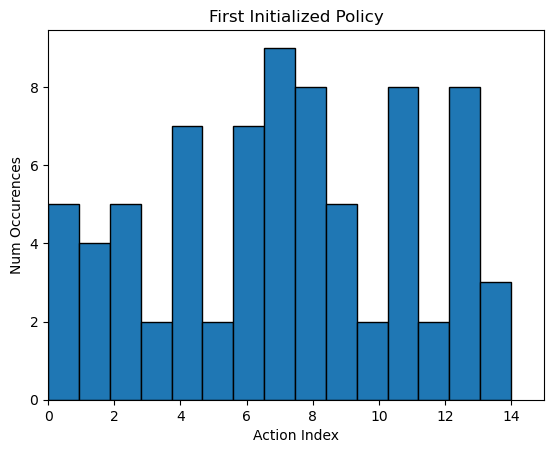

[9, 1, 1, 11, 0, 7, 11, 6, 7, 0, 5, 0, 1, 8, 2, 13, 7, 11, 13, 2, 10, 0, 4, 6, 7, 14, 12, 8, 8, 11, 9, 13, 13, 13, 9, 6, 9, 3, 2, 10, 4, 4, 11, 13, 7, 6, 14, 8, 6, 4, 0, 4, 6, 13, 3, 7, 8, 6, 8, 2, 7, 8, 14, 13, 7, 1, 11, 5, 8, 4, 11, 12, 7, 11, 2, 9, 4]
Episode 18 terminated with reward of 0.0 (step 77)


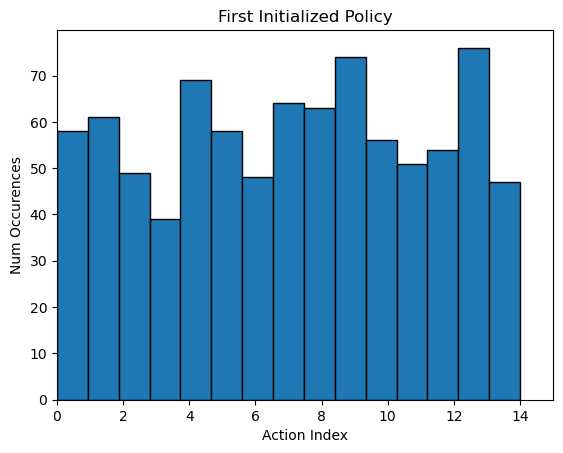

[0, 12, 4, 7, 0, 13, 0, 4, 0, 5, 14, 13, 13, 12, 13, 13, 11, 10, 10, 8, 14, 3, 11, 10, 13, 3, 9, 13, 2, 2, 13, 1, 7, 10, 9, 9, 2, 4, 13, 5, 10, 6, 9, 2, 6, 10, 5, 5, 4, 9, 5, 0, 9, 5, 1, 7, 1, 6, 13, 7, 5, 10, 13, 5, 9, 9, 6, 4, 8, 7, 0, 0, 11, 7, 5, 4, 12, 13, 0, 9, 4, 10, 2, 10, 13, 0, 8, 8, 9, 10, 6, 0, 9, 13, 12, 4, 9, 14, 7, 8, 11, 3, 0, 7, 13, 2, 5, 6, 3, 9, 14, 13, 9, 3, 11, 1, 7, 12, 13, 9, 2, 2, 13, 8, 8, 8, 13, 13, 0, 12, 5, 8, 9, 0, 7, 2, 5, 10, 12, 9, 10, 2, 6, 8, 7, 4, 10, 8, 1, 4, 11, 7, 10, 9, 5, 1, 2, 4, 1, 5, 11, 7, 13, 4, 9, 5, 7, 13, 0, 7, 10, 7, 8, 4, 12, 0, 11, 5, 7, 0, 11, 12, 6, 6, 6, 9, 1, 6, 0, 7, 3, 9, 12, 13, 2, 4, 0, 7, 8, 1, 12, 7, 4, 0, 3, 7, 8, 11, 9, 0, 6, 14, 14, 4, 9, 9, 13, 6, 7, 12, 0, 7, 7, 9, 13, 10, 12, 9, 12, 10, 7, 6, 8, 12, 2, 5, 14, 4, 2, 11, 4, 8, 9, 10, 10, 1, 12, 4, 8, 14, 13, 11, 12, 4, 10, 11, 0, 12, 13, 3, 7, 6, 13, 8, 1, 0, 11, 4, 10, 11, 12, 6, 13, 8, 5, 14, 5, 6, 8, 10, 2, 4, 8, 4, 1, 13, 4, 0, 8, 8, 1, 4, 13, 1, 6, 1, 13, 7, 8, 13, 3

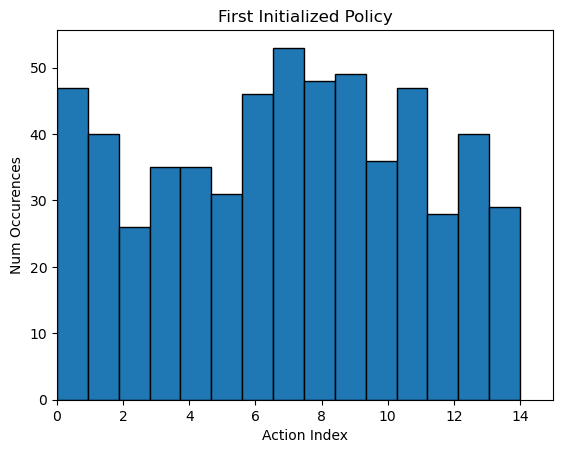

[6, 12, 11, 9, 13, 7, 4, 3, 6, 8, 12, 3, 5, 5, 0, 13, 1, 13, 3, 14, 8, 10, 1, 0, 4, 0, 9, 3, 3, 0, 3, 12, 3, 14, 2, 5, 13, 3, 3, 7, 2, 8, 7, 13, 8, 0, 0, 4, 8, 7, 4, 13, 13, 3, 0, 8, 7, 9, 6, 7, 2, 10, 7, 3, 8, 1, 10, 0, 0, 7, 13, 1, 3, 11, 6, 6, 0, 3, 12, 1, 9, 12, 11, 8, 11, 9, 4, 12, 1, 11, 7, 12, 9, 9, 12, 1, 12, 11, 6, 6, 14, 11, 6, 13, 14, 9, 7, 9, 2, 11, 10, 7, 13, 8, 10, 5, 1, 4, 3, 1, 13, 0, 0, 4, 5, 10, 13, 11, 2, 14, 6, 4, 5, 14, 11, 4, 4, 7, 14, 11, 12, 1, 14, 2, 4, 0, 9, 7, 8, 7, 13, 0, 4, 8, 1, 6, 5, 13, 4, 4, 10, 1, 5, 5, 10, 0, 0, 6, 3, 2, 0, 9, 10, 11, 7, 7, 10, 0, 9, 13, 10, 12, 12, 6, 6, 11, 9, 0, 0, 6, 13, 6, 12, 7, 12, 13, 9, 1, 10, 5, 12, 8, 4, 3, 11, 14, 0, 11, 2, 13, 5, 0, 8, 2, 7, 11, 4, 1, 5, 1, 3, 6, 4, 8, 0, 9, 0, 9, 0, 12, 7, 9, 1, 13, 10, 5, 9, 13, 6, 0, 2, 12, 7, 6, 2, 11, 8, 8, 1, 11, 11, 14, 2, 7, 1, 9, 13, 8, 0, 10, 11, 10, 7, 5, 2, 11, 0, 1, 7, 7, 2, 6, 9, 1, 14, 9, 0, 9, 1, 5, 4, 9, 6, 3, 6, 10, 3, 10, 7, 9, 9, 4, 10, 14, 6, 13, 13, 11, 14, 6, 0, 7, 

In [16]:

for ep in range(20): # number of episodes
    terminated, truncated = False, False
    total_reward = 0
    obs, _ = env.reset()
    step = 0
    hist = []
    while not terminated and not truncated:
        action, _ = model.predict(obs)
        hist.append(action.item())
        # out = wrapped_env.step(action)
        obs, reward, truncated, terminated, info = env.step(action.item())
        total_reward += reward
        step += 1
    plt.hist(hist, bins=15, edgecolor="black")
    plt.xlim(0, 15)
    plt.xlabel("Action Index")
    plt.ylabel("Num Occurences")
    plt.title("First Initialized Policy")
    plt.show()

    print(hist)
    
    print(f"Episode {ep + 1} terminated with reward of {total_reward} (step {step})")

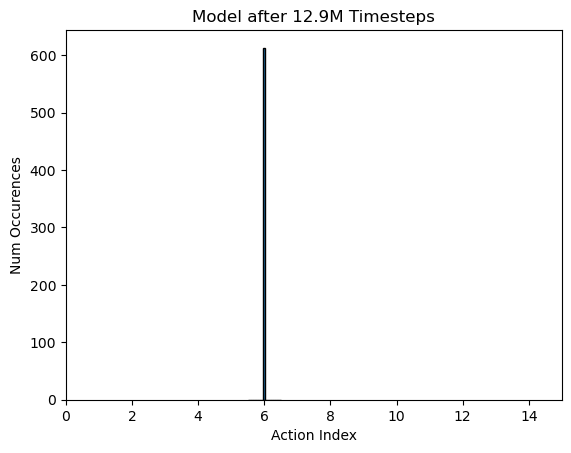

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 

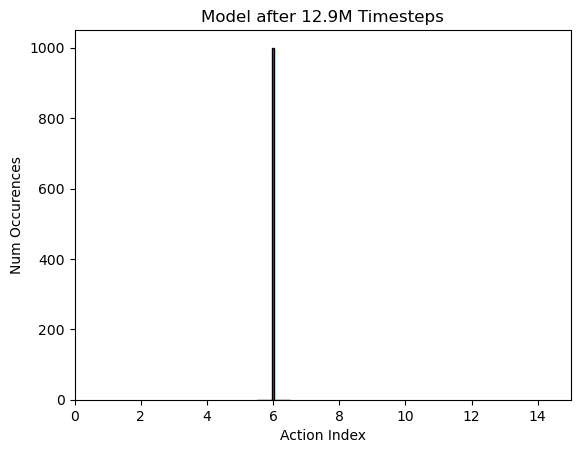

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 

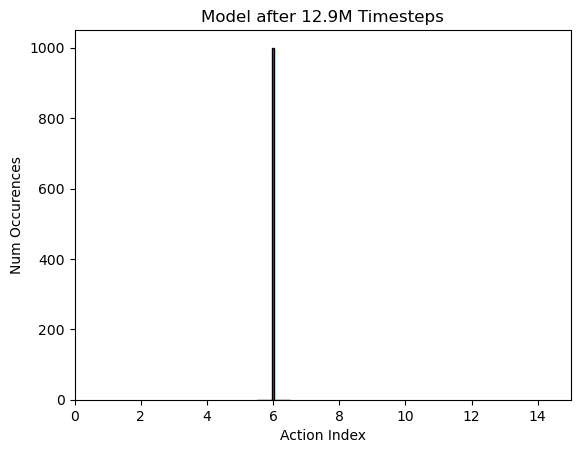

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 

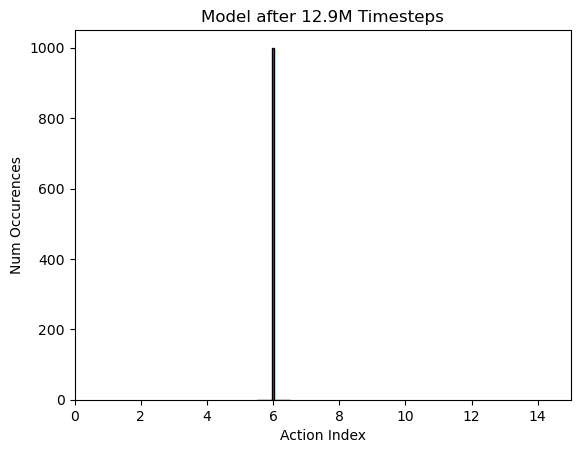

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 

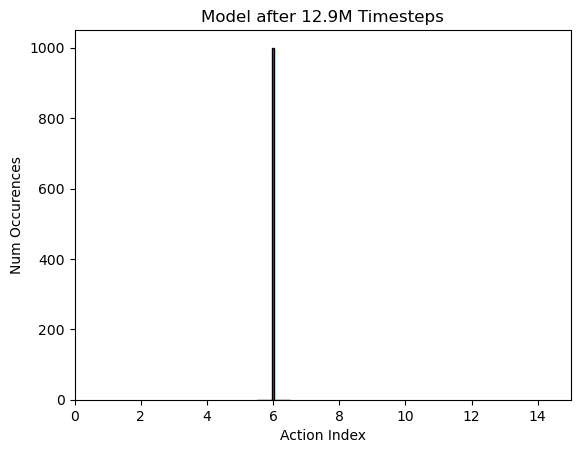

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 

In [18]:

for ep in range(5): # number of episodes
    terminated, truncated = False, False
    total_reward = 0
    obs, _ = env.reset()
    step = 0
    hist = []
    while not terminated and not truncated:
        action, _ = model_loaded.predict(obs)
        hist.append(action.item())
        # out = wrapped_env.step(action)
        obs, reward, truncated, terminated, info = env.step(action.item())
        total_reward += reward
        step += 1
    plt.hist(hist, bins=15, edgecolor="black")
    plt.xlim(0, 15)
    plt.xlabel("Action Index")
    plt.ylabel("Num Occurences")
    plt.title("Model after 12.9M Timesteps")
    plt.show()

    print(hist)
    
    print(f"Episode {ep + 1} terminated with reward of {total_reward} (step {step})")